# Decoding an upcoming decision bias from pre-stimulus neural activity

**Question.** In a perceptual decision task, can we read out the animal's *upcoming
decision bias* from population neural activity recorded **before the stimulus even
appears**? If so, the brain carries a decision-relevant prior/bias state ahead of the
sensory evidence, rather than forming the whole decision from the stimulus.

**Dataset.** DANDI **000409** — *IBL, Brain Wide Map*. Head-fixed mice perform the IBL
`biasedChoiceWorld` task: a Gabor patch appears on the left or right at one of several
contrasts (including **0% contrast**, where there is no sensory evidence), and the mouse
turns a wheel to bring it to center. Neuropixels probes record hundreds of units per
session. Two features make this task ideal for the question:

1. **A block-wise prior (the imposed bias).** The stimulus side is not 50/50; it is drawn
   in blocks with `probability_left` ∈ {0.2, 0.5, 0.8}. Mice learn the block and bias
   their choices accordingly. This prior is the *decision bias* we want to decode.
2. **An enforced quiescence period (a clean pre-stimulus window).** Each trial requires
   ≥ 400 ms of wheel stillness before the stimulus is shown, so a pre-stimulus window has
   no movement to confound the neural read-out.

**Approach.** For each session we take a **pre-stimulus window (−400 to 0 ms** relative to
`gabor_stimulus_onset_time`), count each unit's spikes in that window, and train a
cross-validated logistic decoder to predict (a) the **upcoming choice** and (b) the
**upcoming block prior / bias**. We compare against label-shuffle nulls, trace decoding
accuracy across time relative to onset, and tie the neural signal to behavior on the
zero-contrast trials where choice is pure internal bias.

We use six sessions from six different mice to show the effect is robust.

## Setup

The analysis is organized into small modules in this directory:
`db_pipeline.py` (streaming NWB load + spike-count tensors), `build_cache.py`
(per-session caching), `analyze.py` (decoding), `make_figs.py` (figures).
Data are streamed from the DANDI S3 store with `remfile` disk caching, so only the
spike times and trial table are fetched — never the raw voltage.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd
np.seterr(all="ignore")
import matplotlib.pyplot as plt
import db_pipeline as P

SESSIONS = {
    "NYU-11": "sub-NYU-11/sub-NYU-11_ses-6713a4a7-faed-4df2-acab-ee4e63326f8d_desc-processed_behavior+ecephys.nwb",
    "NYU-30": "sub-NYU-30/sub-NYU-30_ses-77e6dc6a-66ed-433c-b1a2-778c914f523c_desc-processed_behavior+ecephys.nwb",
    "NYU-37": "sub-NYU-37/sub-NYU-37_ses-21d21fc3-4201-4edc-802a-c67b61952548_desc-processed_behavior+ecephys.nwb",
    "NYU-46": "sub-NYU-46/sub-NYU-46_ses-d32876dd-8303-4720-8e7e-20678dc2fd71_desc-processed_behavior+ecephys.nwb",
    "NYU-40": "sub-NYU-40/sub-NYU-40_ses-8ca740c5-e7fe-430a-aa10-e74e9c3cbbe8_desc-processed_behavior+ecephys.nwb",
    "NYU-39": "sub-NYU-39/sub-NYU-39_ses-91a3353a-2da1-420d-8c7c-fad2fedfdd18_desc-processed_behavior+ecephys.nwb",
}

## 1. Load one session and inspect the trial structure

We stream a single session with Pynapple and look at the behavioral variables that
define the task. Note the 0% contrast trials and the block structure in `prob_left`.

In [2]:
name0, path0 = "NYU-11", SESSIONS["NYU-11"]
nwbfile, df, units = P.load_session(path0)
d0 = P.clean_trials(df)
print(f"{name0}: {len(d0)} decided trials, {len(units.index)} sorted units")
print("contrast levels (%):", np.unique(d0.contrast.values))
print("block priors P(left):", np.unique(d0.prob_left.values, return_counts=True))
print("choices:", d0.choice.value_counts().to_dict())
print("zero-contrast trials:", int((d0.contrast == 0).sum()))
d0.head()

NYU-11: 556 decided trials, 898 sorted units
contrast levels (%): [  0.     6.25  12.5   25.   100.  ]
block priors P(left): (array([0.2, 0.5, 0.8]), array([249,  88, 219]))
choices: {'clockwise': 322, 'counter_clockwise': 234}
zero-contrast trials: 61


,onset,contrast,side,choice,prob_left,quiescence,rewarded,move_onset,y
0,268.974705,100.00,left,counter_clockwise,0.5,0.610104,False,312.828017,0
1,381.061090,100.00,left,clockwise,0.5,0.618698,True,385.421017,1
2,389.144322,6.25,right,clockwise,0.5,0.559975,False,404.071017,1
3,472.173027,0.00,left,counter_clockwise,0.5,0.652146,False,491.698017,0
4,496.409761,12.50,left,clockwise,0.5,0.483541,True,534.950017,1


## 2. Build peri-onset spike-count tensors (all sessions)

For each session we compute a `(trials × units × time-bin)` tensor of spike counts in
100 ms bins spanning −1.0 to +0.6 s around stimulus onset. Units below 1 Hz mean rate
are dropped. Results are cached to `cache/` so re-runs are fast. This streams ~0.5 GB
per session on the first run.

In [3]:
os.makedirs("cache", exist_ok=True)
EDGES = np.round(np.arange(-1.0, 0.601, 0.1), 3)
if not os.path.exists("cache/NYU-39_T.npy"):
    from tqdm import tqdm
    for nm, pth in tqdm(SESSIONS.items(), desc="sessions"):
        if os.path.exists(f"cache/{nm}_T.npy"):
            continue
        _, dfi, ui = P.load_session(pth)
        di = P.clean_trials(dfi)
        dur = float(ui.time_support.tot_length())
        us = P.select_units(ui, min_rate=1.0, session_dur=dur)
        T = P.peri_onset_tensor(us, di.onset.values, EDGES)
        np.save(f"cache/{nm}_T.npy", T)
        di.to_parquet(f"cache/{nm}_d.parquet")
np.save("cache/edges.npy", EDGES)
print("tensors ready:", [f for f in os.listdir("cache") if f.endswith("_T.npy")])

tensors ready: ['NYU-30_T.npy', 'NYU-11_T.npy', 'NYU-37_T.npy', 'NYU-39_T.npy', 'NYU-46_T.npy', 'NYU-40_T.npy']


## 3. Validate: peri-onset population activity, split by block

Left: trial-averaged firing (units sorted by pre-stimulus rate) rises sharply after
onset, confirming stimulus-driven responses. Right: the mean population rate during the
**pre-stimulus window (cyan)** is already slightly separated between the left-biased and
right-biased blocks — the seed of what the decoder will exploit.

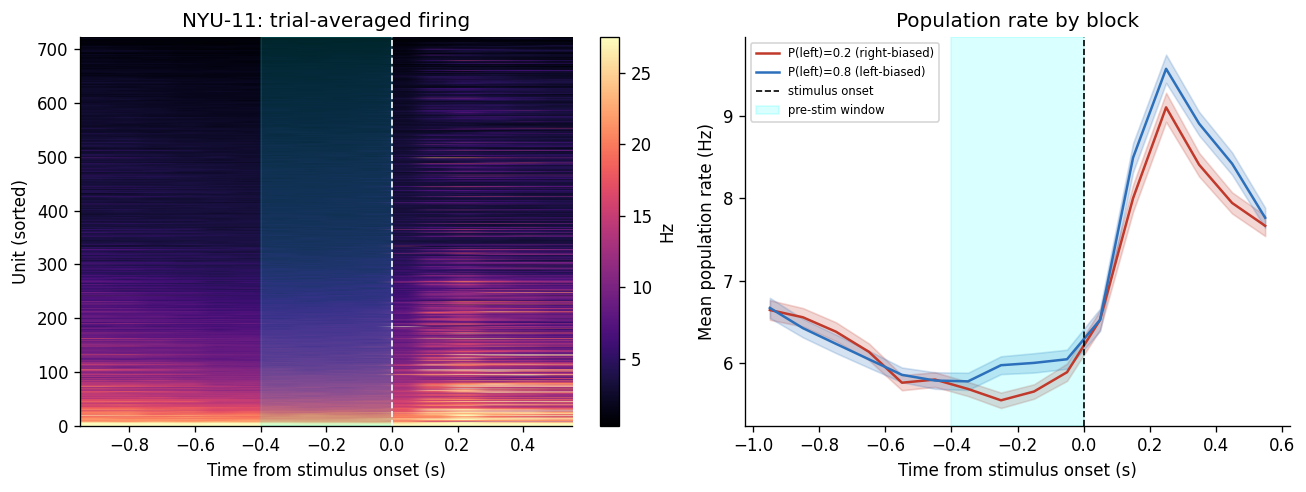

In [4]:
from make_figs import fig_raw, fig_decode, fig_temporal, fig_behavior_link
fig_raw("NYU-11")
from IPython.display import Image, display
display(Image("figures/fig1_raw_validation.png"))

## 4. Decode the upcoming decision from pre-stimulus activity

For each session we sum spike counts in the −400 to 0 ms window and fit an L2-regularized
logistic decoder (5-fold cross-validation, balanced classes) to predict:

- **upcoming choice** — clockwise vs counter-clockwise wheel turn, and
- **upcoming bias** — the block prior (`P(left)=0.2` vs `0.8`; neutral 0.5 trials excluded).

Significance is assessed against a 200-iteration label-shuffle null.

In [5]:
from analyze import load, CENTERS, PRESTIM, targets, cv_auc
rng = np.random.default_rng(0)
rows, prestim_proba = [], {}
for nm in SESSIONS:
    T, d = load(nm)
    Xpre = T[:, :, PRESTIM].sum(2).astype(float)
    y_choice, blk, y_block = targets(d)
    a_c, b_c, p_c, null_c = cv_auc(Xpre, y_choice, n_shuffle=200, rng=rng)
    a_b, b_b, p_b, null_b = cv_auc(Xpre[blk], y_block, n_shuffle=200, rng=rng)
    rows.append(dict(session=nm, n=len(d), n_units=Xpre.shape[1],
                     choice_auc=a_c, choice_bacc=b_c, choice_p=(null_c >= a_c).mean(),
                     choice_null95=np.percentile(null_c, 95),
                     block_auc=a_b, block_bacc=b_b, block_p=(null_b >= a_b).mean(),
                     block_null95=np.percentile(null_b, 95)))
    prestim_proba[nm] = (d, p_c, blk)
    print(f"{nm}: choice AUC={a_c:.3f} (p={rows[-1]['choice_p']:.3f}) | "
          f"bias AUC={a_b:.3f} (p={rows[-1]['block_p']:.3f})")
res = pd.DataFrame(rows)
res.to_csv("cache/decode_results.csv", index=False)
res[["session", "n", "n_units", "choice_auc", "choice_p", "block_auc", "block_p"]]

NYU-11: choice AUC=0.597 (p=0.000) | bias AUC=0.753 (p=0.000)


NYU-30: choice AUC=0.652 (p=0.000) | bias AUC=0.814 (p=0.000)


NYU-37: choice AUC=0.644 (p=0.000) | bias AUC=0.850 (p=0.000)


NYU-46: choice AUC=0.537 (p=0.155) | bias AUC=0.714 (p=0.000)


NYU-40: choice AUC=0.636 (p=0.000) | bias AUC=0.798 (p=0.000)


NYU-39: choice AUC=0.584 (p=0.015) | bias AUC=0.797 (p=0.000)


,session,n,n_units,choice_auc,choice_p,block_auc,block_p
0,NYU-11,556,723,0.597096,0.000,0.752893,0.0
1,NYU-30,784,475,0.651915,0.000,0.813506,0.0
2,NYU-37,541,640,0.644186,0.000,0.849990,0.0
3,NYU-46,424,488,0.536618,0.155,0.713640,0.0
4,NYU-40,545,849,0.635570,0.000,0.797990,0.0
5,NYU-39,508,702,0.583803,0.015,0.796735,0.0


The **upcoming bias (block prior)** decodes far above chance in **all six sessions**
(AUC ≈ 0.71–0.85). The **upcoming choice** decodes above chance in 5/6 sessions
(AUC ≈ 0.54–0.65). Both signals exist *before the stimulus appears*.

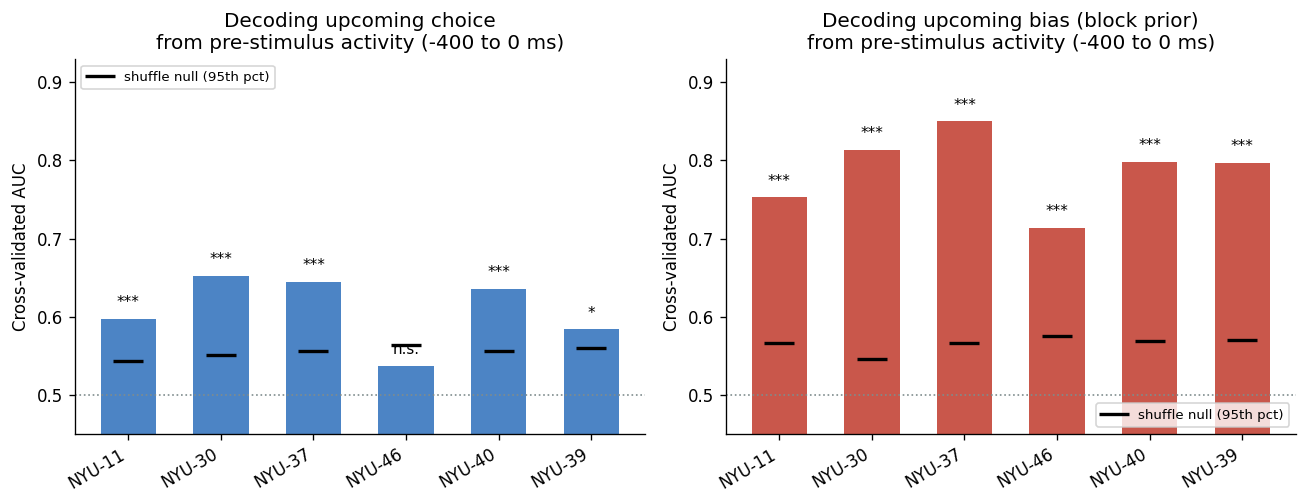

In [6]:
fig_decode(res)
display(Image("figures/fig2_prestim_decoding.png"))

## 5. When does the bias appear? Sliding-window decoding across time

We repeat the decode in each 100 ms bin from −1.0 to +0.6 s relative to onset. The bias
signal is present and roughly flat *throughout the pre-stimulus period*, then both
signals jump at stimulus onset (the sensory/decision epoch). The pre-onset elevation is
the key result: the decision bias is carried by neural activity before the stimulus.

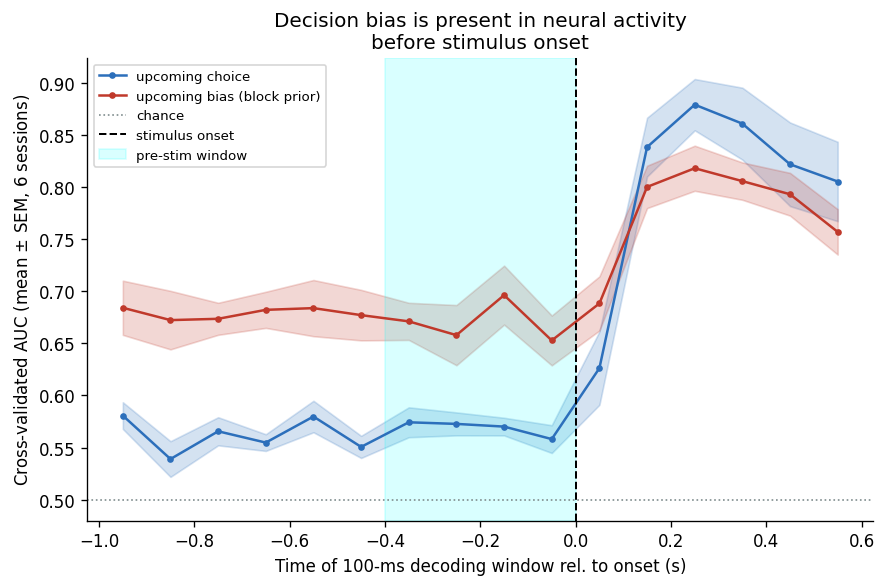

In [7]:
nb = len(CENTERS)
choice_curve = np.full((len(SESSIONS), nb), np.nan)
block_curve = np.full((len(SESSIONS), nb), np.nan)
for si, nm in enumerate(SESSIONS):
    T, d = load(nm)
    y_choice, blk, y_block = targets(d)
    for k in range(nb):
        Xk = T[:, :, k].astype(float)
        choice_curve[si, k] = cv_auc(Xk, y_choice)[0]
        block_curve[si, k] = cv_auc(Xk[blk], y_block)[0]
np.savez("cache/temporal.npz", choice=choice_curve, block=block_curve, centers=CENTERS)
fig_temporal(choice_curve, block_curve)
display(Image("figures/fig3_temporal_decoding.png"))

## 6. Tie the neural bias to behavior on zero-contrast trials

On 0% contrast trials there is no sensory evidence, so the choice is driven purely by
internal bias. (a) Behavioral psychometric curves shift with the block prior. (b) The
zero-contrast choice probability increases monotonically with the block prior
(0.2 → 0.5 → 0.8). (c) Sorting zero-contrast trials by the **pre-stimulus decoder's
output** recovers a monotonic gradient in the actual choice: the neural pre-stimulus
state predicts the upcoming biased choice when the stimulus carries no information.

Pooled zero-contrast choice AUC from pre-stimulus activity = 0.641


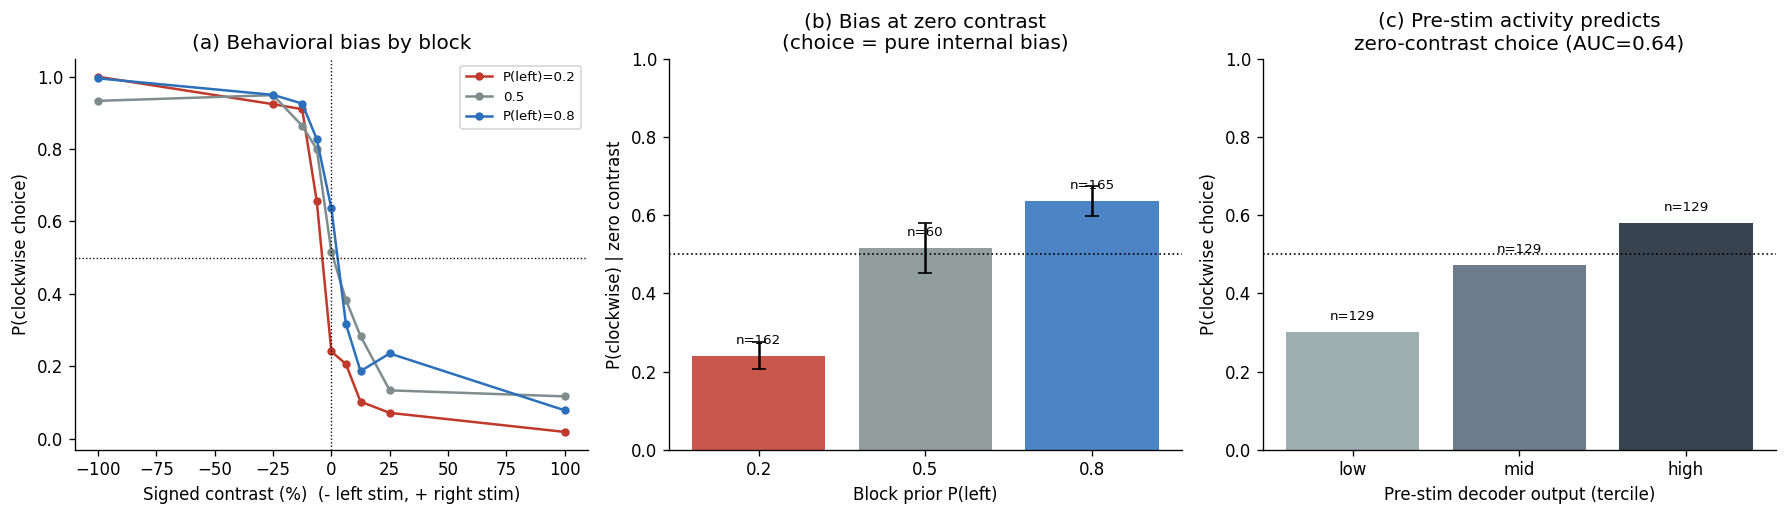

In [8]:
auc0 = fig_behavior_link(prestim_proba)
print(f"Pooled zero-contrast choice AUC from pre-stimulus activity = {auc0:.3f}")
display(Image("figures/fig4_behavior_link.png"))

## Conclusion

In the IBL perceptual decision task, an **upcoming decision bias is decodable from
population neural activity 400 ms before stimulus onset**. The experimentally imposed
block prior is read out at AUC ≈ 0.71–0.85 in every session, and the upcoming choice at
AUC ≈ 0.54–0.65. The signal is present throughout a movement-free pre-stimulus window and
jumps only when the stimulus arrives. On zero-contrast trials, where choice reflects
pure bias, the pre-stimulus decoder predicts the animal's choice (pooled AUC ≈ 0.64).
Together these results demonstrate that the brain holds a decision-relevant bias state
before the evidence, and that this state shapes the behavioral choice.